## Function 3 — Week 8: SFGP with qLogNEI Acquisition (15 MLL Restarts)

This notebook processes the **Week 8** updated data for Function 3 and proposes the next sample point for Week 9 using the same strategy as Week 7:

- **Surrogate**: Single-Fidelity GP with Matérn-2.5 kernel, ARD (3 lengthscales), noise ≥ 1e-6, manual z-score output standardisation
- **Training**: 15-restart MLL optimisation with `torch.manual_seed` seeding and `copy.deepcopy` best model selection
- **Acquisition**: qLogNoisyExpectedImprovement (qLogNEI) — 10 restarts, 512 raw samples
- **Data**: 23 cumulative samples

All hyperparameters are identical to Week 7 — only the data file path and sample count change.

In [1]:
import copy
import warnings
import numpy as np
import torch
import matplotlib.pyplot as plt

from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.constraints import GreaterThan
from gpytorch.likelihoods import GaussianLikelihood
from botorch.acquisition.logei import qLogNoisyExpectedImprovement
from botorch.optim import optimize_acqf

print("All imports successful.")

All imports successful.


### Hyperparameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Kernel | Matérn-2.5 | Smoother than 1.5; suitable for compound mixture landscapes |
| ARD dims | 3 | One lengthscale per compound (A, B, C) |
| Noise floor | 1e-6 | Tight noise constraint for relatively clean outputs |
| N_RESTARTS (MLL) | 15 | Multi-restart MLL to escape local optima in hyperparameter space |
| LENGTHSCALE_INIT | 0.25 | Starting lengthscale for each restart |
| SIGNAL_VAR_INIT | 1.0 | Starting outputscale |
| NOISE_VAR_INIT | 0.1 | Starting noise variance |
| N_RESTARTS (acq) | 10 | Multi-start for acquisition optimisation |
| RAW_SAMPLES | 512 | Sobol candidate pool |

In [2]:
# ─── Constants (identical to Week 7) ──────────────────────────────────────────
N_RESTARTS       = 15    # MLL restarts: escape local optima in hyperparameter space
LENGTHSCALE_INIT = 0.25  # Starting lengthscale for each restart
SIGNAL_VAR_INIT  = 1.0   # Starting outputscale
NOISE_VAR_INIT   = 0.1   # Starting noise variance
JITTER           = 1e-6  # Numerical stability jitter
DIM              = 3
DIM_NAMES        = ['Compound A', 'Compound B', 'Compound C']

# Acquisition constants
ACQ_RESTARTS  = 10
ACQ_RAW       = 512
BOUNDS = torch.tensor([[0.0, 0.0, 0.0],
                        [0.999999, 0.999999, 0.999999]], dtype=torch.float64)

print("Constants:")
print(f"  N_RESTARTS (MLL):  {N_RESTARTS}")
print(f"  LENGTHSCALE_INIT:  {LENGTHSCALE_INIT}")
print(f"  SIGNAL_VAR_INIT:   {SIGNAL_VAR_INIT}")
print(f"  NOISE_VAR_INIT:    {NOISE_VAR_INIT}")
print(f"  ACQ_RESTARTS:      {ACQ_RESTARTS}")
print(f"  ACQ_RAW:           {ACQ_RAW}")

Constants:
  N_RESTARTS (MLL):  15
  LENGTHSCALE_INIT:  0.25
  SIGNAL_VAR_INIT:   1.0
  NOISE_VAR_INIT:    0.1
  ACQ_RESTARTS:      10
  ACQ_RAW:           512


### Step 1: Load Week 8 Data

Load the cumulative Week 8 data (23 total samples). Apply manual z-score output standardisation.

In [3]:
# Load Week 8 cumulative data
X_raw = np.load('../../data/f3/updated_inputs - Week 8.npy')
y_raw = np.load('../../data/f3/updated_outputs - Week 8.npy')

# Validate dimensions and ranges
assert X_raw.shape == (23, 3), f"Expected (23, 3), got {X_raw.shape}"
assert y_raw.shape == (23,), f"Expected (23,), got {y_raw.shape}"
assert np.all((X_raw >= 0.0) & (X_raw <= 1.0)), "Inputs out of [0, 1] range"
assert not np.any(np.isnan(y_raw)), "Outputs contain NaN"

# Manual z-score output standardisation
y_mean = y_raw.mean()
y_std  = y_raw.std()
y_std_safe = max(y_std, 1e-8)
y_standardised = (y_raw - y_mean) / y_std_safe

# Convert to tensors
X_train = torch.tensor(X_raw, dtype=torch.float64)
Y_train = torch.tensor(y_standardised, dtype=torch.float64).unsqueeze(-1)

print(f"Week 8 Data: {X_raw.shape[0]} samples, {X_raw.shape[1]} dimensions")
print(f"Output range (raw):          [{y_raw.min():.6f}, {y_raw.max():.6f}]")
print(f"Output range (standardised): [{y_standardised.min():.6f}, {y_standardised.max():.6f}]")
print(f"y_mean={y_mean:.6f}, y_std={y_std:.6f}")
print(f"Best observed value: {y_raw.max():.6f} at index {y_raw.argmax()}")
print(f"Best observed point: {X_raw[y_raw.argmax()]}")

# Per-dimension ranges with compound labels
print(f"\nPer-dimension ranges:")
for d in range(DIM):
    print(f"  {DIM_NAMES[d]:>12}: [{X_raw[:, d].min():.6f}, {X_raw[:, d].max():.6f}]")

# Display tabular data
print(f"\n{'Idx':>4}  {'Compound A':>10}  {'Compound B':>10}  {'Compound C':>10}  {'y (raw)':>12}")
print("-" * 55)
for i in range(len(y_raw)):
    marker = " ← best" if i == y_raw.argmax() else ""
    print(f"{i:>4}  {X_raw[i,0]:>10.6f}  {X_raw[i,1]:>10.6f}  {X_raw[i,2]:>10.6f}  {y_raw[i]:>12.6f}{marker}")

Week 8 Data: 23 samples, 3 dimensions
Output range (raw):          [-0.398926, -0.031427]
Output range (standardised): [-3.996103, 0.780853]
y_mean=-0.091500, y_std=0.076931
Best observed value: -0.031427 at index 21
Best observed point: [0.063229 0.711381 0.36739 ]

Per-dimension ranges:
    Compound A: [0.016095, 1.000000]
    Compound B: [0.035487, 0.999999]
    Compound C: [0.014859, 0.990882]

 Idx  Compound A  Compound B  Compound C       y (raw)
-------------------------------------------------------
   0    0.171525    0.343917    0.248737     -0.112122
   1    0.242114    0.644074    0.272433     -0.087963
   2    0.534906    0.398501    0.173389     -0.111415
   3    0.492581    0.611593    0.340176     -0.034835
   4    0.134622    0.219917    0.458206     -0.048008
   5    0.345523    0.941360    0.269363     -0.110621
   6    0.151837    0.439991    0.990882     -0.398926
   7    0.645503    0.397143    0.919771     -0.113869
   8    0.746912    0.284196    0.226300     -0

### Step 2: Fit Surrogate — 15-Restart MLL Training

SingleTaskGP with `ScaleKernel(MaternKernel(ν=2.5, ard_num_dims=3))` and `GaussianLikelihood(noise ≥ 1e-6)`.
Each restart re-initialises hyperparameters and selects the model with the lowest negative MLL.

In [4]:
best_mll_value = float('inf')
best_model = None

for restart in range(N_RESTARTS):
    torch.manual_seed(restart)
    
    # Build fresh model each restart
    likelihood = GaussianLikelihood(
        noise_constraint=GreaterThan(JITTER)
    )
    covar_module = ScaleKernel(
        MaternKernel(nu=2.5, ard_num_dims=DIM)
    )
    model_i = SingleTaskGP(
        X_train, Y_train,
        covar_module=covar_module,
        likelihood=likelihood,
    )
    
    # Initialise hyperparameters
    model_i.covar_module.base_kernel.lengthscale = torch.tensor([[LENGTHSCALE_INIT] * DIM])
    model_i.covar_module.outputscale = torch.tensor(SIGNAL_VAR_INIT)
    model_i.likelihood.noise_covar.noise = torch.tensor([NOISE_VAR_INIT])
    
    mll_i = ExactMarginalLogLikelihood(model_i.likelihood, model_i)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            fit_gpytorch_mll(mll_i)
        except Exception as e:
            print(f"  Restart {restart:>2}: FAILED — {e}")
            continue
    
    # Evaluate negative MLL
    model_i.eval()
    with torch.no_grad():
        output = model_i(X_train)
        neg_mll = -mll_i(output, Y_train.squeeze(-1)).item()
    
    if neg_mll < best_mll_value:
        best_mll_value = neg_mll
        best_model = copy.deepcopy(model_i)
        print(f"  Restart {restart:>2}: neg_mll = {neg_mll:.4f}  ← new best")
    else:
        print(f"  Restart {restart:>2}: neg_mll = {neg_mll:.4f}")

assert best_model is not None, "All restarts failed!"
model = best_model
model.eval()

# Report final hyperparameters
ls = model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
noise = model.likelihood.noise_covar.noise.detach().item()
outputscale = model.covar_module.outputscale.detach().item()

print(f"\nBest model (neg_mll = {best_mll_value:.4f}):")
print(f"  Lengthscales: {', '.join(f'{DIM_NAMES[d]}={ls[d]:.4f}' for d in range(DIM))}")
print(f"  Output scale: {outputscale:.4f}")
print(f"  Noise:        {noise:.6f}")

/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning:

  Restart  0: neg_mll = 115.1569  ← new best
  Restart  1: neg_mll = 115.1569
  Restart  2: neg_mll = 115.1569
  Restart  3: neg_mll = 115.1569
  Restart  4: neg_mll = 115.1569


/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning:

  Restart  5: neg_mll = 115.1569
  Restart  6: neg_mll = 115.1569
  Restart  7: neg_mll = 115.1569
  Restart  8: neg_mll = 115.1569
  Restart  9: neg_mll = 115.1569
  Restart 10: neg_mll = 115.1569
  Restart 11: neg_mll = 115.1569
  Restart 12: neg_mll = 115.1569
  Restart 13: neg_mll = 115.1569
  Restart 14: neg_mll = 115.1569

Best model (neg_mll = 115.1569):
  Lengthscales: Compound A=0.8737, Compound B=0.0252, Compound C=2742.7121
  Output scale: 1.2346
  Noise:        0.000001


/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning:

### Step 3: Optimise Acquisition — qLogNoisyExpectedImprovement

`qLogNEI` with `X_baseline` set to training data and `prune_baseline=True`.

In [5]:
# Build qLogNEI acquisition function
nei = qLogNoisyExpectedImprovement(
    model=model,
    X_baseline=X_train,
    prune_baseline=True,
)

# Optimise bounds
bounds_t = torch.tensor(BOUNDS, dtype=torch.float64)

candidate, acq_value = optimize_acqf(
    acq_function=nei,
    bounds=bounds_t,
    q=1,
    num_restarts=ACQ_RESTARTS,
    raw_samples=ACQ_RAW,
)

next_x = candidate.detach().squeeze().numpy()
print(f"Acquisition value: {acq_value.item():.6f}")
print(f"\nProposed next sample:")
for d in range(DIM):
    print(f"  {DIM_NAMES[d]:>12}: {next_x[d]:.6f}")
print(f"\nBest observed (raw): {y_raw.max():.6f}")
print(f"Best observed point: {X_raw[y_raw.argmax()]}")

/var/folders/dr/xw6m41dn1hdb8jp1_zyyh5g80000gn/T/ipykernel_89860/1619922331.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bounds_t = torch.tensor(BOUNDS, dtype=torch.float64)


Acquisition value: -1.144382

Proposed next sample:
    Compound A: 0.266369
    Compound B: 0.200543
    Compound C: 0.464891

Best observed (raw): -0.031427
Best observed point: [0.063229 0.711381 0.36739 ]


### Step 4: Pairwise 2D Slice Visualisation

Three subplots showing the posterior mean for each pair of dimensions, with the third dimension fixed at the best observed point. White contours show ±2σ uncertainty.

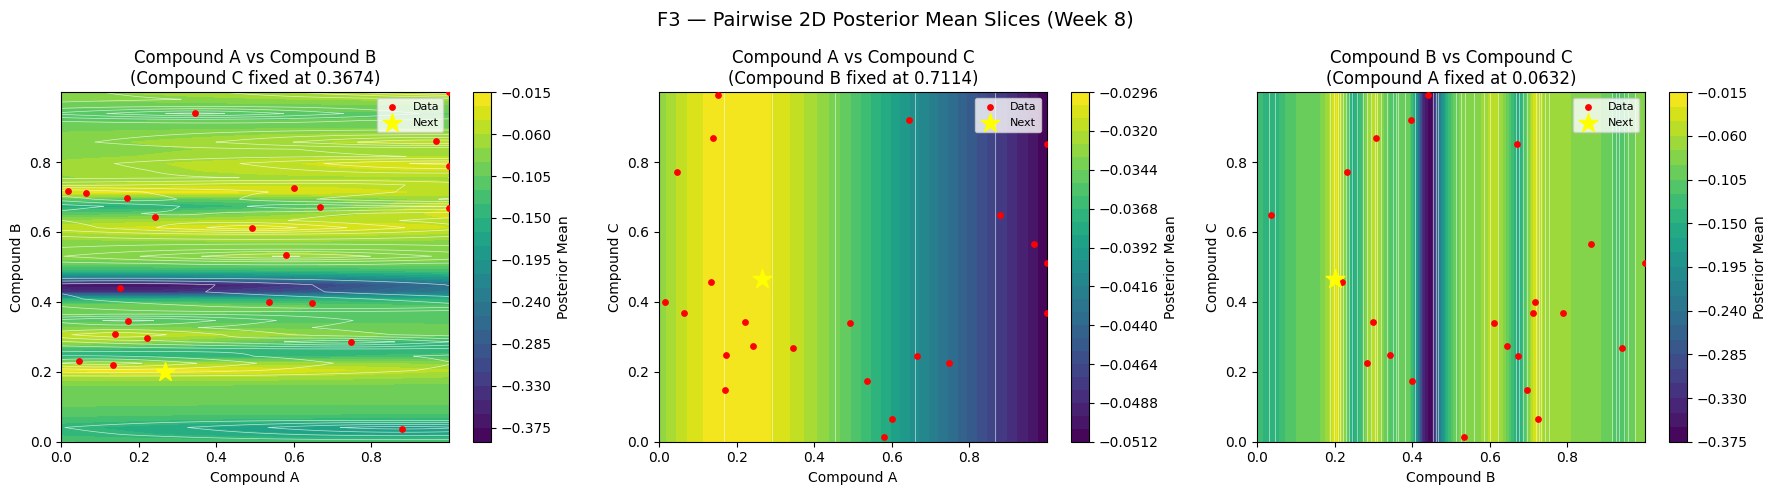

In [6]:
best_idx = y_raw.argmax()
best_point = X_raw[best_idx]

pairs = [(0, 1), (0, 2), (1, 2)]
GRID_RES = 50

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (d1, d2) in zip(axes, pairs):
    # Third dimension index
    d3 = [d for d in range(DIM) if d not in (d1, d2)][0]
    
    # Build 2D grid
    g1 = np.linspace(0, 0.999999, GRID_RES)
    g2 = np.linspace(0, 0.999999, GRID_RES)
    G1, G2 = np.meshgrid(g1, g2)
    
    # Fill grid with best_point for the fixed dim
    grid_points = np.full((GRID_RES * GRID_RES, DIM), best_point[d3])
    grid_points[:, d1] = G1.ravel()
    grid_points[:, d2] = G2.ravel()
    
    X_grid = torch.tensor(grid_points, dtype=torch.float64)
    
    with torch.no_grad():
        posterior = model.posterior(X_grid)
        mean_std = posterior.mean.squeeze().numpy()
        std_std  = posterior.variance.squeeze().sqrt().numpy()
    
    # De-standardise mean for display
    mean_raw = mean_std * y_std_safe + y_mean
    std_raw  = std_std * y_std_safe
    
    Mean = mean_raw.reshape(GRID_RES, GRID_RES)
    Std  = std_raw.reshape(GRID_RES, GRID_RES)
    
    # Mean surface
    c = ax.contourf(G1, G2, Mean, levels=30, cmap='viridis')
    plt.colorbar(c, ax=ax, label='Posterior Mean')
    
    # 2σ contours (white)
    ax.contour(G1, G2, Std, levels=5, colors='white', linewidths=0.5, alpha=0.7)
    
    # Scatter training data (projected)
    ax.scatter(X_raw[:, d1], X_raw[:, d2], c='red', s=15, zorder=5, label='Data')
    ax.scatter(next_x[d1], next_x[d2], c='yellow', marker='*', s=200, zorder=6, label='Next')
    
    ax.set_xlabel(DIM_NAMES[d1])
    ax.set_ylabel(DIM_NAMES[d2])
    ax.set_title(f'{DIM_NAMES[d1]} vs {DIM_NAMES[d2]}\n({DIM_NAMES[d3]} fixed at {best_point[d3]:.4f})')
    ax.legend(fontsize=8)

plt.suptitle('F3 — Pairwise 2D Posterior Mean Slices (Week 8)', fontsize=14)
plt.tight_layout()
plt.show()

### Step 5: Convergence Plot

Running maximum of observed values across all samples. Vertical dashed lines show phase boundaries.

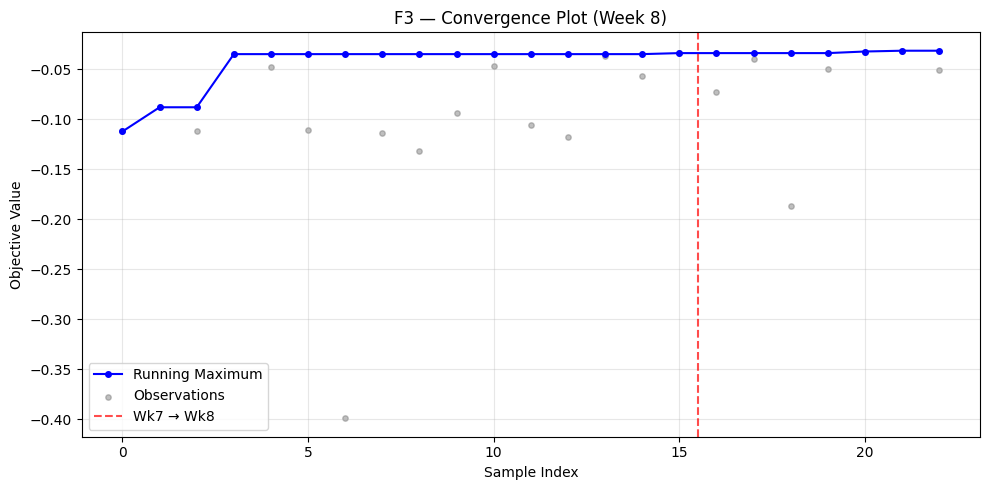

Best value: -0.031427 at index 21
Total samples: 23


In [7]:
# Running maximum convergence
running_max = np.maximum.accumulate(y_raw)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(y_raw)), running_max, 'b-o', markersize=4, label='Running Maximum')
ax.scatter(range(len(y_raw)), y_raw, c='gray', s=15, alpha=0.5, label='Observations')

# Phase boundaries
ax.axvline(x=15.5, color='red', linestyle='--', alpha=0.7, label='Wk7 → Wk8')

ax.set_xlabel('Sample Index')
ax.set_ylabel('Objective Value')
ax.set_title('F3 — Convergence Plot (Week 8)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best value: {y_raw.max():.6f} at index {y_raw.argmax()}")
print(f"Total samples: {len(y_raw)}")

### Step 6: Format Submission

Clamp proposed point to [0, 0.999999] and check for duplicates in existing data.

In [8]:
# Clamp to valid range
proposed = np.clip(next_x, 0.0, 0.999999)

# Duplicate check
distances = np.linalg.norm(X_raw - proposed, axis=1)
min_dist = distances.min()
is_duplicate = min_dist < 1e-6

if is_duplicate:
    print("⚠️  WARNING: Proposed point is a near-duplicate of existing data!")
    print(f"   Closest existing point at distance {min_dist:.8f}")
else:
    print(f"✓ No duplicate (min distance to existing data: {min_dist:.6f})")

print(f"\n{'='*50}")
print(f"F3 — Week 8 Submission")
print(f"{'='*50}")
for d in range(DIM):
    print(f"  {DIM_NAMES[d]:>12}: {proposed[d]:.6f}")
print(f"\nFormatted query: ({', '.join(f'{v:.6f}' for v in proposed)})")
print(f"{'='*50}")

✓ No duplicate (min distance to existing data: 0.133332)

F3 — Week 8 Submission
    Compound A: 0.266369
    Compound B: 0.200543
    Compound C: 0.464891

Formatted query: (0.266369, 0.200543, 0.464891)
